# 1. Introduction

# **Dataset: Titanic | 891 passengers | 12 features**

- Question: Which passenger characteristics most influenced survival?

- Following passenger characteristics influenced survival

 **Sex, Fare and Age were influential factor for survivial**






In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

# 2. Data Overview

1. df.shape
2. df.info()
3. df.describe()
4. df.isnull().sum()

In [2]:
#shape of dataframe
df.shape

(891, 12)

In [3]:
#first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
#describe -
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
#info - Dtype, null count, column information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
#check null
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Data Cleaning
- Handle Missing Values
    1. Age - fill NA values with median of Age
    2. Cabin - Drop column Cabin
    3. Embarked - Drop 2 rows with missing Embarked
- Encode
    1. Sex_encoded - map male/female as 0/1
    2. AgeGroup - age category

In [7]:
df['Age']

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


In [8]:
df.fillna({'Age':df['Age'].median()},inplace=True)

In [9]:
df['Age']

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,28.0
889,26.0


In [10]:
#2. Cabin - Drop column Cabin
df = df.drop(columns="Cabin")

In [11]:
#3. Embarked - Drop 2 rows with missing Embarked
df.dropna(subset=["Embarked"],inplace=True)

In [12]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [13]:
#astype()   --> Survival and Pclass variable have int64
  # We need them to be categorical for further analysis

#Survived as 0 or 1 -categorical values
#df['Survived']= df['Survived'].astype(pd.CategoricalDtype())

#Pclass category as 1, 2, 3 values
#df['Pclass'] = df['Pclass'].astype(pd.CategoricalDtype())
print(df.dtypes)


#Both these variables are needed for plotting purposes with groupBy and mean needs to be calculated
#SO they need to be int and not categorical


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object


In [14]:
#map(), apply()
#Sex_encoded  - male/females encoding them as 0/1
df['Sex_encoded'] = df['Sex'].map({'male':0,'female':1})
df



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Sex_encoded
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,0


In [15]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
Sex_encoded      int64
dtype: object


In [16]:
#apply() - apply a function to a dataframe/series
  # apply() is used to pass that condtion across columns

#Age group we divide the age into groups using a function
df['Age_group'] = df['Age'].apply(lambda x:'Child' if x<13 else 'Teen' if x<18 else 'Adult' if x<61 else 'Senior')
df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Sex_encoded,Age_group
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,0,Adult
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,1,Adult
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,1,Adult
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,0,Adult


# 3. Univariate Analysis

1. Age distribution
2. Survival Count
3. Pclass distribution

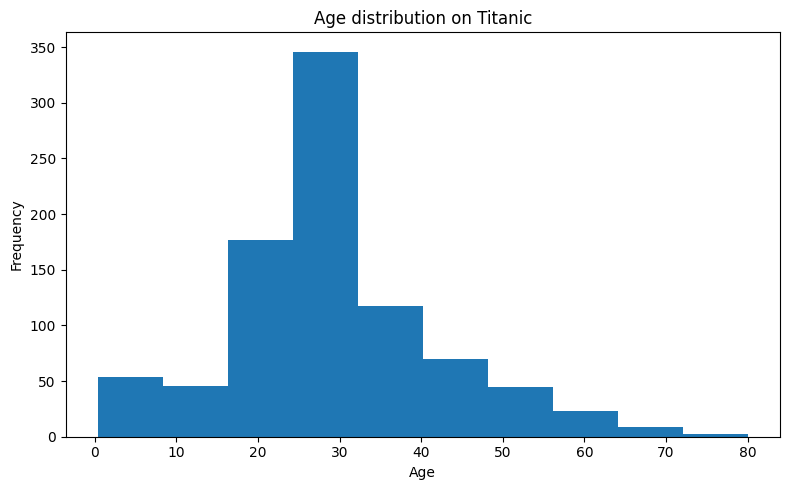

In [17]:
#1.Age distribution
  #(histogram) -> gives a continuous distribution

fig,ax = plt.subplots(figsize=(8,5))
ax.hist(x=df['Age'])#,bins=20
ax.set_title("Age distribution on Titanic")
ax.set_xlabel("Age")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()




> **Age histograms clearly depicts that most passengers on Titanic were people between the age 25-30.**


> **With a few people (outliers) at 60+ age**.





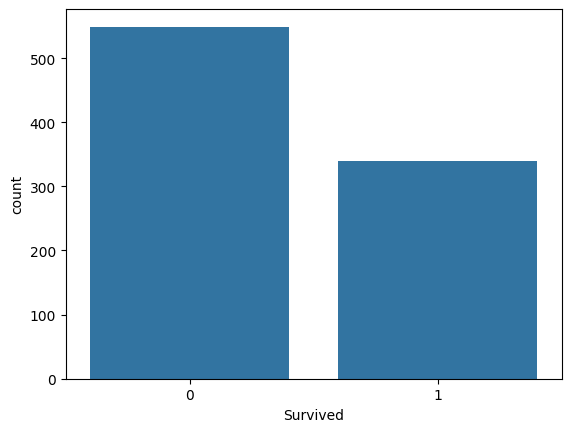

In [18]:
#2. Survival Count
sns.countplot(data=df,x="Survived")
plt.show()

In [19]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,340


> **Count plot shows that comparatively less people survived on Titanic**


> **549 people wer dead, while only 342 survived**

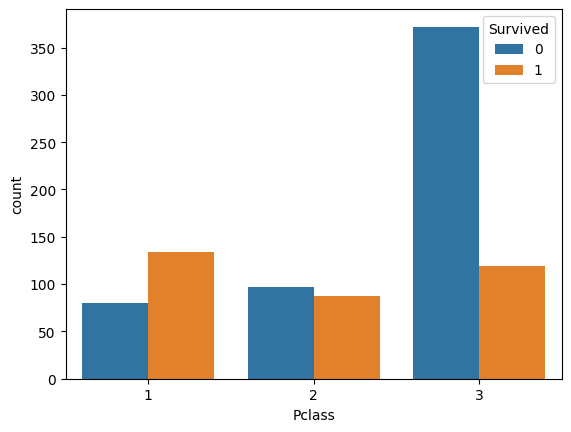

In [20]:
#3. Pclass distribution
sns.countplot(data=df,x="Pclass",hue="Survived")
plt.show()

> **Pclass Countplot highlights that passenger class determined survival rate on Titanic**


> **Pclass 3 had the highest dead count**

# 4. Bivariate Analysis

    1. Survival rate by Pclass
    2. Survival rate by Sex
    3. Age vs Fare coloured by survival
    4. Survival by AgeGroup
    

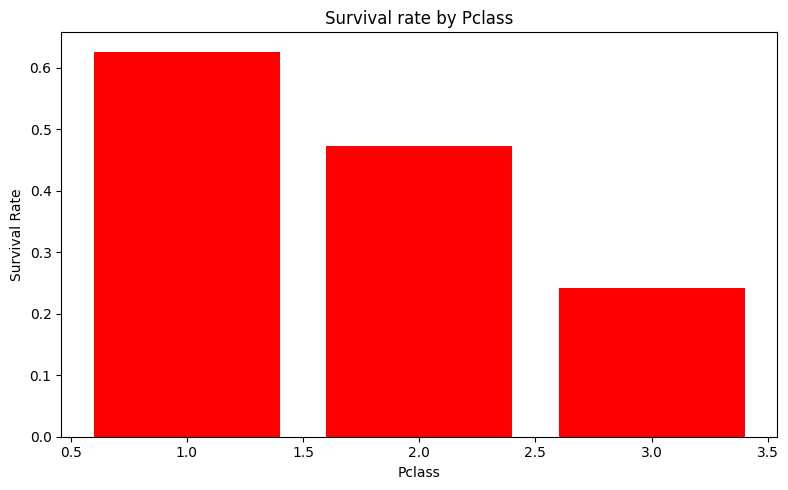

In [21]:
#1. Survival rate by Pclass
    # we need avg survival rate across Pclass
    # Groupby - Divides Pclass into 3 clear groups(index : values) and returns 3 bunched into one group

survival_by_Pclass = df.groupby('Pclass')['Survived'].mean()
    #survival_by_Pclass.index
    #survival_by_Pclass.values


fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x=survival_by_Pclass.index, height=survival_by_Pclass.values,color="red")
ax.set_title("Survival rate by Pclass")
ax.set_xlabel("Pclass")
ax.set_ylabel("Survival Rate")
plt.tight_layout()
plt.show()




> **Bar chart shows the mean surivial for each Pclass**


> **Pclass-3 had the worst surival rate of 25%, whereas Pclass showed highest overall survival rate of 60%**

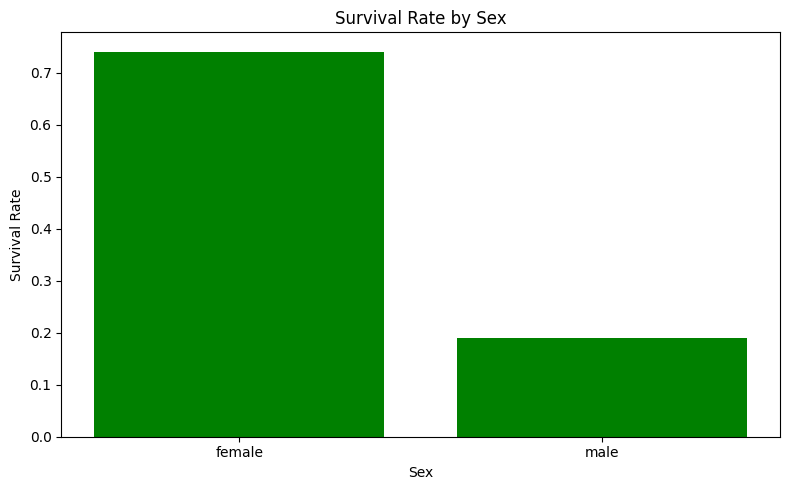

In [22]:
# 2. Survival rate by Sex
survival_by_sex = df.groupby('Sex')['Survived'].mean()
survival_by_sex
fig,ax = plt.subplots(figsize=(8,5))

ax.bar(x=survival_by_sex.index,height=survival_by_sex.values, color="green")
ax.set_title("Survival Rate by Sex")
ax.set_xlabel("Sex")
ax.set_ylabel("Survival Rate")
plt.tight_layout()
plt.show()

> **Gender was the strongest survival predictor**


> **Female passengers had a 74% survival**

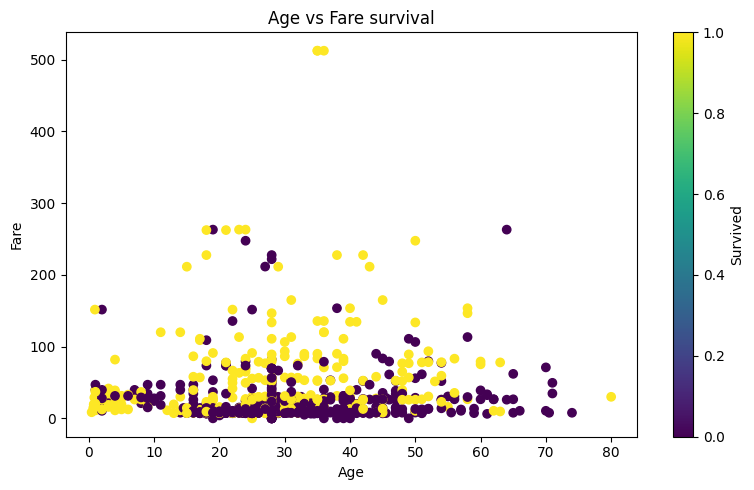

In [23]:
# 3. Age vs Fare coloured by survival

fig,ax = plt.subplots(figsize=(8,5))

ax.scatter(data=df, x='Age', y='Fare',c='Survived')
ax.set_title("Age vs Fare survival")
ax.set_xlabel("Age")
ax.set_ylabel("Fare")

plt.colorbar(ax.collections[0],label="Survived")
plt.tight_layout()
plt.show()


In [24]:
df['FareBand'] = pd.cut(df['Fare'], bins=[0, 50, 100, 200, 600])
df.groupby('FareBand', observed=True)['Survived'].mean()

,Survived
FareBand,
"(0, 50]",0.324022
"(50, 100]",0.647619
"(100, 200]",0.757576
"(200, 600]",0.700000


> **Passengers payng over 50 had nearly double the survival rate than those paying under 50(65% vs 32%), suggesting fare - as a proxy for passenger class was a strong determinant of survival**
---

> **Higher fare which indicated closer to first class and hence first towards the lifeboats**


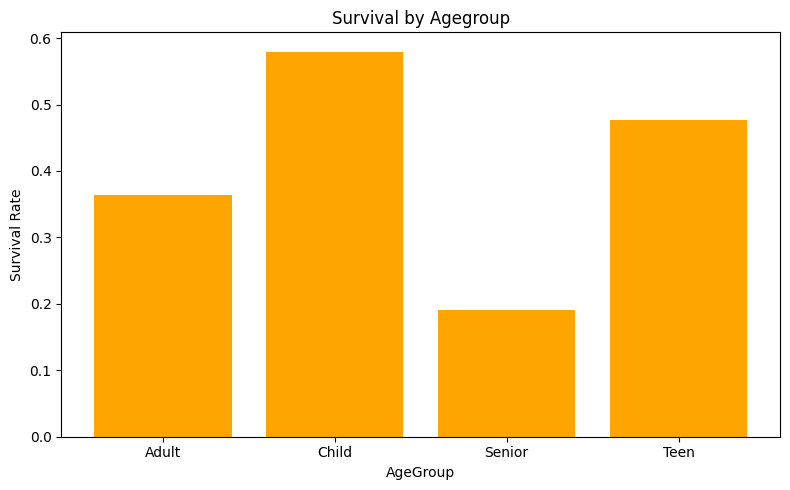

In [25]:
#4. Survival by AgeGroup
survival_by_AgeGroup = df.groupby('Age_group')['Survived'].mean()
fig,ax = plt.subplots(figsize=(8,5))

ax.bar(x=survival_by_AgeGroup.index, height=survival_by_AgeGroup.values,color="orange")
ax.set_title("Survival by Agegroup")
ax.set_xlabel("AgeGroup")
ax.set_ylabel("Survival Rate")

plt.tight_layout()
plt.show()

In [26]:
df.groupby('Age_group')['Survived'].mean()

,Survived
Age_group,
Adult,0.364238
Child,0.579710
Senior,0.190476
Teen,0.477273



> **Children had the highest survival rate at 58%, compared to 37% for adults and 23% for seniors, suggesting age played a role in evacuation priority**



# 5. Multivariate Analysis

    1. Correlation heatmap (top features)
    2. Pairplot coloured by survival
    3. FacetGrid - Age distribution by Pclass and Sex

In [27]:
#1. corelation heatmap
  # specifies relation across variables to showcase dependability
corr_heatmap = df.corr(numeric_only=True)
corr_heatmap

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_encoded
PassengerId,1.000000,-0.005028,-0.035330,0.031319,-0.057686,-0.001657,0.012703,-0.043136
Survived,-0.005028,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290,0.541585
Pclass,-0.035330,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193,-0.127741
Age,0.031319,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707,-0.086506
SibSp,-0.057686,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887,0.116348
Parch,-0.001657,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532,0.247508
Fare,0.012703,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000,0.179958
Sex_encoded,-0.043136,0.541585,-0.127741,-0.086506,0.116348,0.247508,0.179958,1.000000


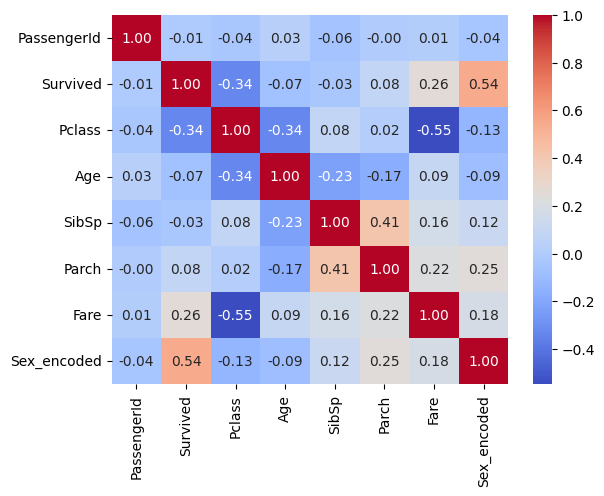

In [28]:
sns.heatmap(corr_heatmap,annot=True,fmt=".2f",cmap="coolwarm")
plt.show()


> **Survival was highly influenced by Sex, Pclass and Fare**

> **Easier to see the visualised insights and verify our findings**



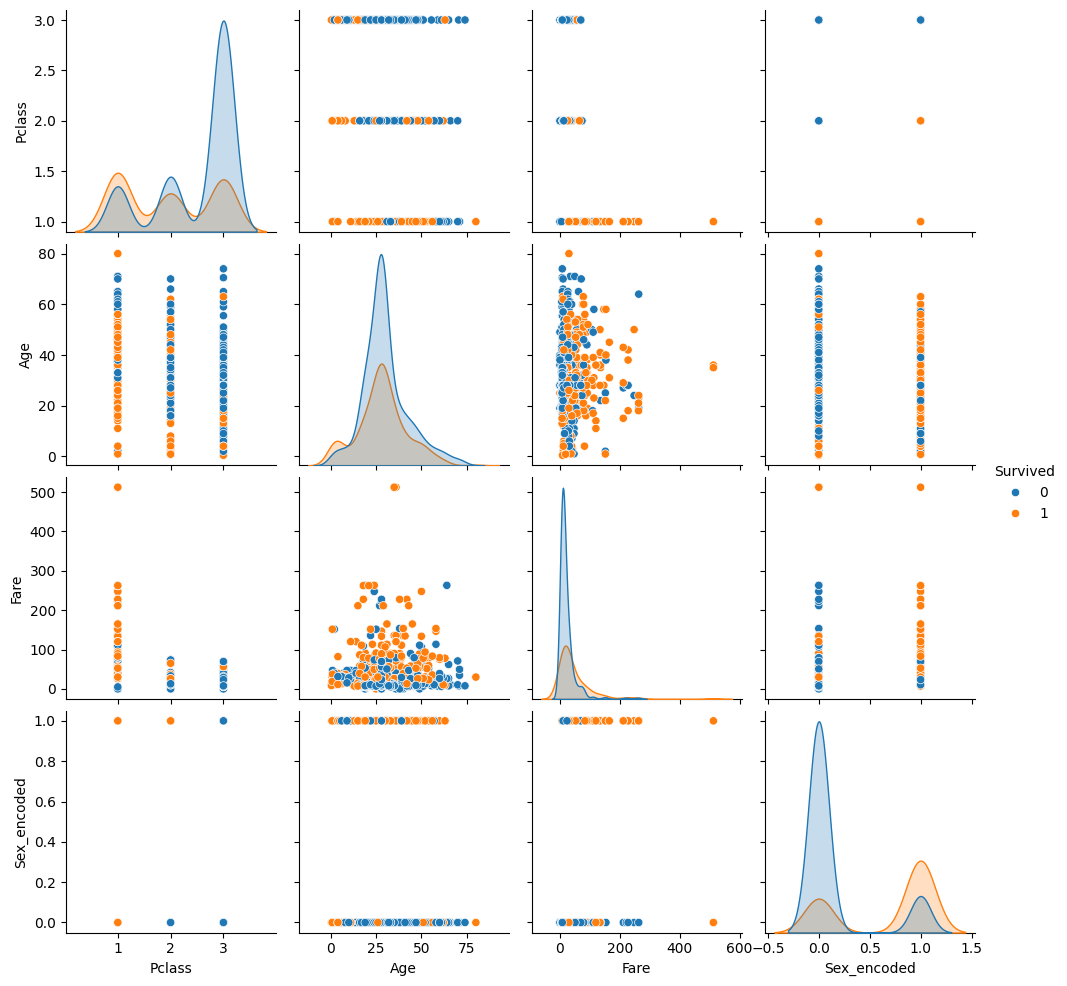

In [29]:
#2. Pairplot coloured by survival
sns.pairplot(data=df,vars=['Pclass','Age','Fare','Sex_encoded'],hue="Survived")
plt.show()


> **pairplot shows that pclass 1 had more surviors than 3, age played a significant factor in getting lifeboats - higher ages less survival, higher fair more survival rate, Females werre given first priority as well, less male survived**


> **The pairplot reveals that Sex_encoded and Fare show the clearest separation between survivors and non-survivors, making them the most promising features for a predictive model**





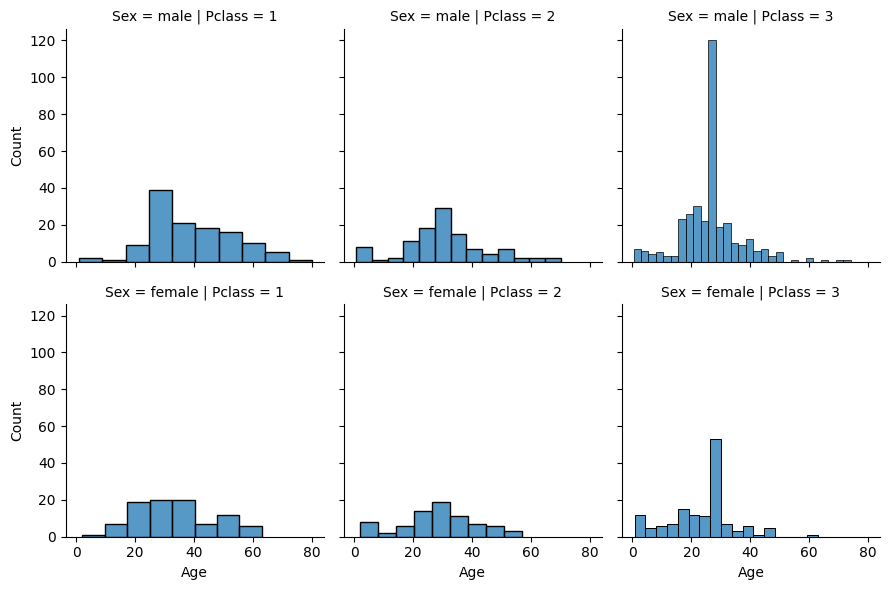

In [30]:
# 3. FacetGrid - Age distribution by Pclass and Sex

g = sns.FacetGrid(df,col="Pclass", row="Sex")
g.map(sns.histplot,'Age')
plt.show()

In [31]:
df.groupby("Pclass")["Age"].mean()

,Age
Pclass,
1,36.688879
2,29.765380
3,25.932627



> **Pclass 3 males were the largest and youngest group (mean age 25.9), with a notable spike around age 20-25, likely reflecting young economic migrants travelling to America**

### Key Insights

1. **Gender was the strongest predictor** -> females had 74% survival vs 19% for males
2. **Fare determined survival** —> passengers paying over £50 had double the survival rate
3. **Children were prioritised** —> 58% survival vs 37% for adults
4. **Class mattered** —> first class had 63% survival vs 24% for third class
5. **Pclass 3 males were largest and youngest group** —> mean age 25.9, likely economic migrants

# Conclusion

This EDA reveals that survival on Titanic was strongly influenced by Gender, Fare/class and age. These features will form tthe basis of a predictive classification model in the next phase.

**Next steps:**
- Build a logistic regression classifier using Sex, Pclass, Fare, Age
- Engineer new features: FareBand, Title, FamilySize
- Evaluate model performance with accuracy, precision, recall